In [1]:
import lightkurve
from lightkurve import DesignMatrix, RegressionCorrector
import matplotlib.pyplot as plot
import numpy
%matplotlib inline
plot.style.use('finny_style.mplstyle')

In [2]:
star_id = 234518605
star_id = f'TIC {star_id}'

In [3]:
search_result = lightkurve.search_targetpixelfile(star_id, mission = 'TESS', cadence = 'long')
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 01,2018,TESS-SPOC,1800,234518605,0.0
1,TESS Sector 02,2018,TESS-SPOC,1800,234518605,0.0
2,TESS Sector 68,2023,TESS-SPOC,200,234518605,0.0
3,TESS Sector 69,2023,TESS-SPOC,200,234518605,0.0


In [4]:
pixel_files = search_result.download_all()

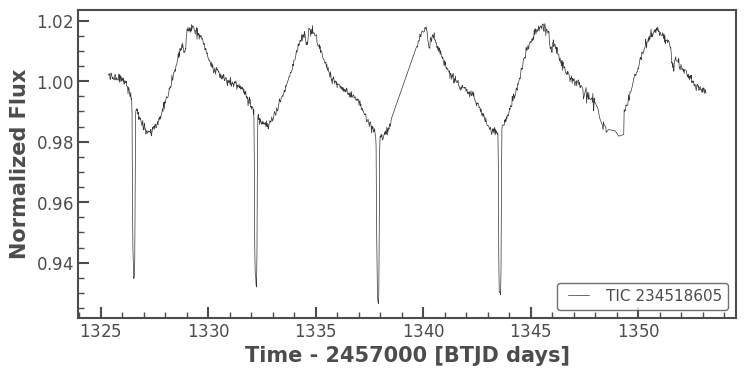

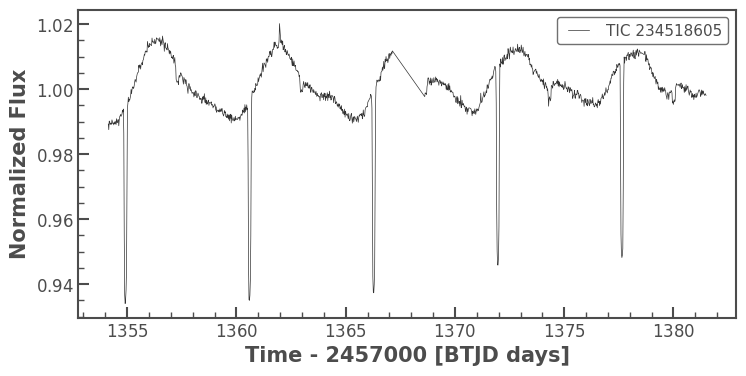

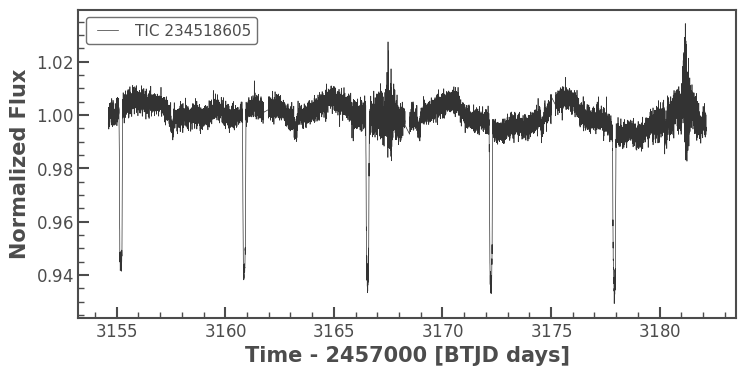

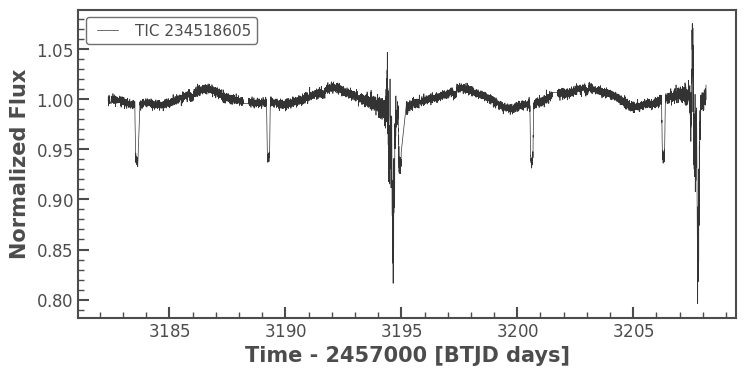

In [5]:
collection = lightkurve.LightCurveCollection(None)
for pixel_file in pixel_files[:]:
    pixel_file = pixel_file[numpy.isfinite(pixel_file.flux).all(axis = (1, 2))]
    pixel_file = pixel_file[numpy.isfinite(pixel_file.flux_err).all(axis = (1, 2))]

    aperture_mask = pixel_file.pipeline_mask
    # aperture_mask = pixel_file.create_threshold_mask(threshold = 10, reference_pixel = 'center')
    uncorrected_lc = pixel_file.to_lightcurve(aperture_mask = aperture_mask)

    # design_matrix = DesignMatrix(pixel_file.flux[:, ~aperture_mask]).pca(5).append_constant()
    # lc = RegressionCorrector(uncorrected_lc).correct(design_matrix)
    lc = uncorrected_lc
    lc = lc.normalize()#.flatten(niters = 10).remove_outliers(10.0)
    lc.plot()
    collection.append(lc)

plot.show()

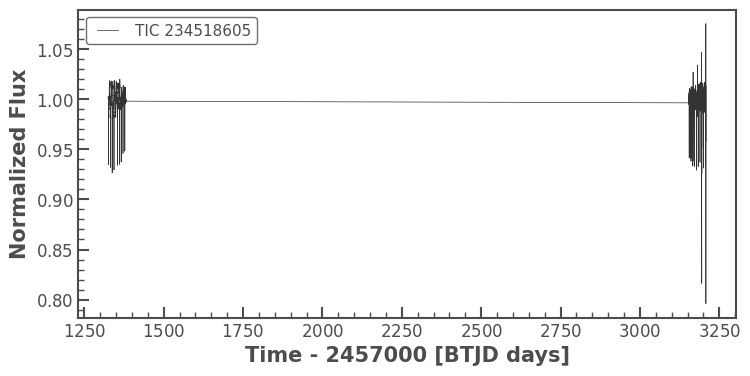

In [6]:
lc = collection[:].stitch()
lc = lc#.flatten(break_tolerance = 10, niters = 10).remove_outliers(sigma = 10.0)
lc.plot()
plot.show()

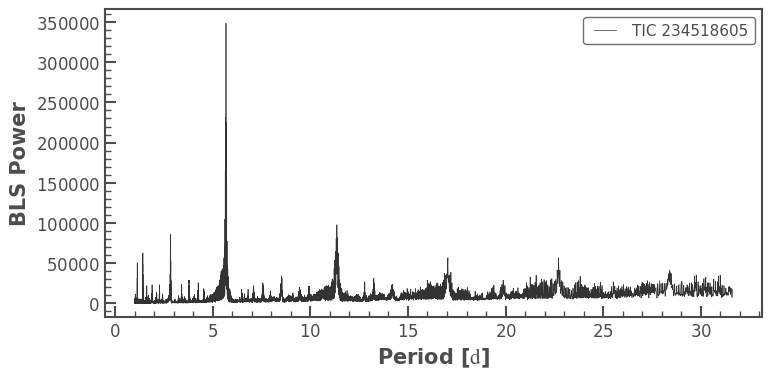

In [7]:
periods = numpy.logspace(0, 1.5, 10 ** 4, base = 10.0)
periodogram = lc.to_periodogram(method = 'boxleastsquares', period = periods, frequency_factor = 10 ** 6)
periodogram.plot()
plot.show()

In [8]:
period = periodogram.period_at_max_power
transit_time = periodogram.transit_time_at_max_power
transit_duration = periodogram.duration_at_max_power
transit_duration = 1

period, transit_time, transit_duration

(<Quantity 5.67904654 d>,
 <Time object: scale='tdb' format='btjd' value=1326.5369596817882>,
 1)

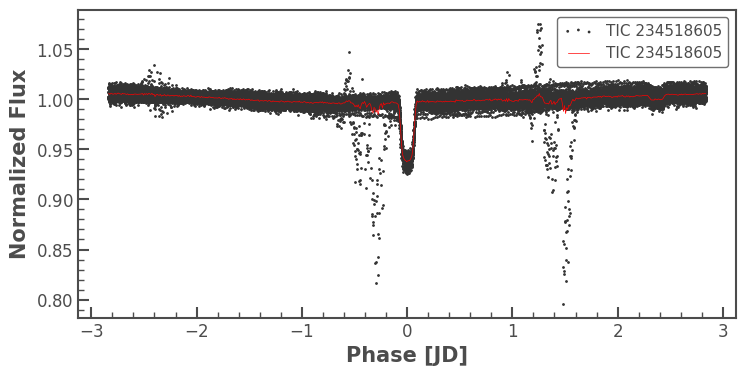

0.062384068965911865

In [9]:
folded_lc = lc.fold(period = period, epoch_time = transit_time)
binned_lc = folded_lc.bin(time_bin_size = 0.01)
ax = folded_lc.scatter()
binned_lc.plot(ax = ax, c = 'r')
d = 1
# ax.set_xlim(-d, d)
# ax.set_ylim(0.995, 1.0025)
plot.show()
1 - numpy.nanmin(binned_lc.flux.value)

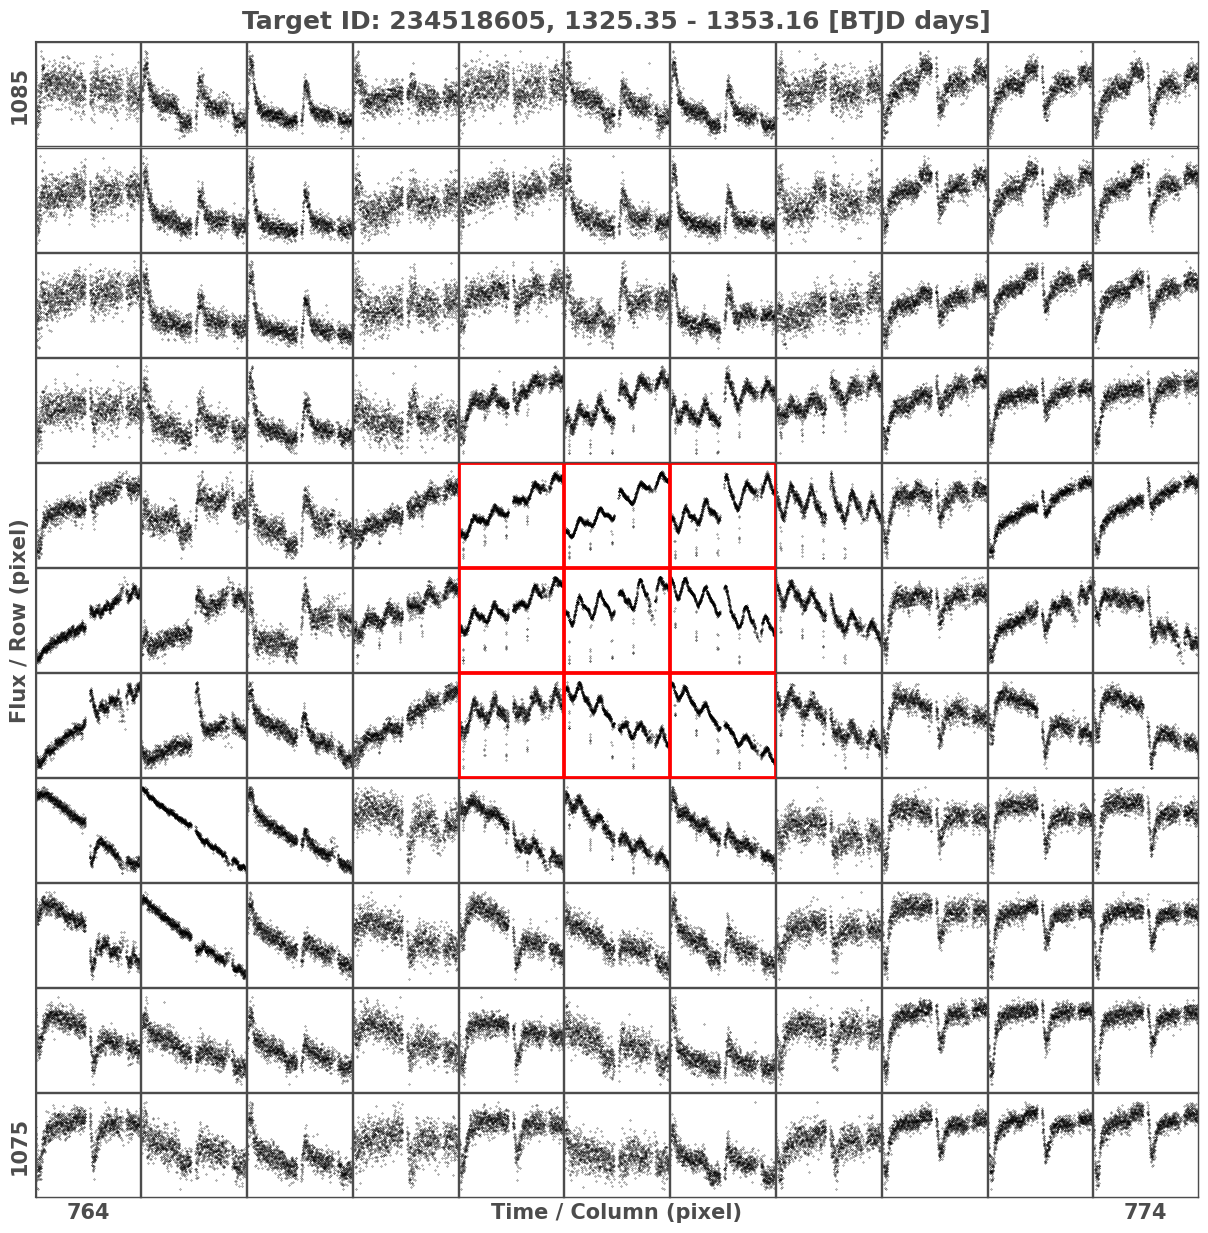

In [10]:
pixel_file = pixel_files[0]
pixel_file.plot_pixels(aperture_mask = pixel_file.pipeline_mask)
plot.show()

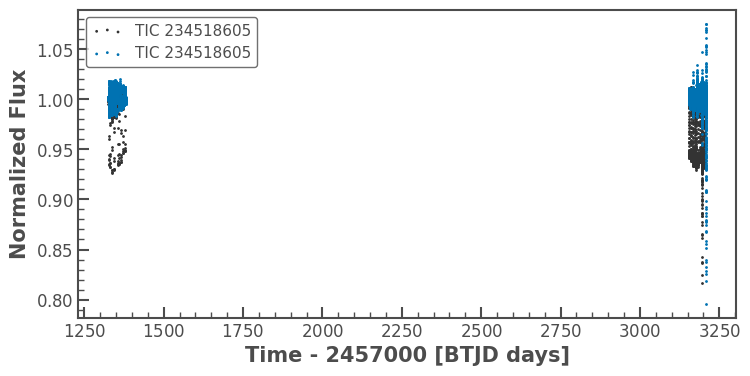

In [11]:
mask = periodogram.get_transit_mask(
            period = period,
            transit_time = transit_time,
            duration = transit_duration
        )

lc_mask = lc[mask]
ax = lc_mask.scatter()
lc = lc[~mask]
lc.scatter(ax = ax)
plot.show()